In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [15]:
df = pd.read_csv('/content/Walmart Data Analysis and Forcasting.csv')

In [16]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [19]:


df["Date"] = pd.to_datetime(df["Date"],format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [22]:
df = df.drop(['Date'],axis=1)

In [23]:
df

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5
...,...,...,...,...,...,...,...,...,...,...
6430,45,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,28
6431,45,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,5
6432,45,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,12
6433,45,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,19


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Weekly_Sales  6435 non-null   float64
 2   Holiday_Flag  6435 non-null   int64  
 3   Temperature   6435 non-null   float64
 4   Fuel_Price    6435 non-null   float64
 5   CPI           6435 non-null   float64
 6   Unemployment  6435 non-null   float64
 7   Year          6435 non-null   int32  
 8   Month         6435 non-null   int32  
 9   Day           6435 non-null   int32  
dtypes: float64(5), int32(3), int64(2)
memory usage: 427.5 KB


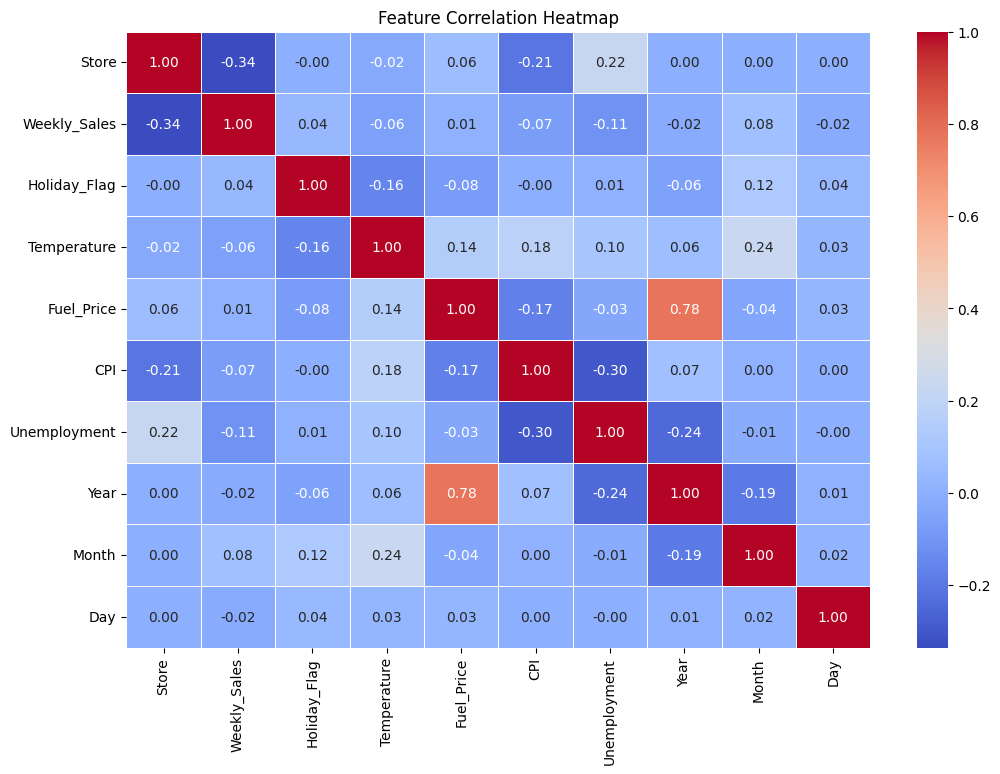

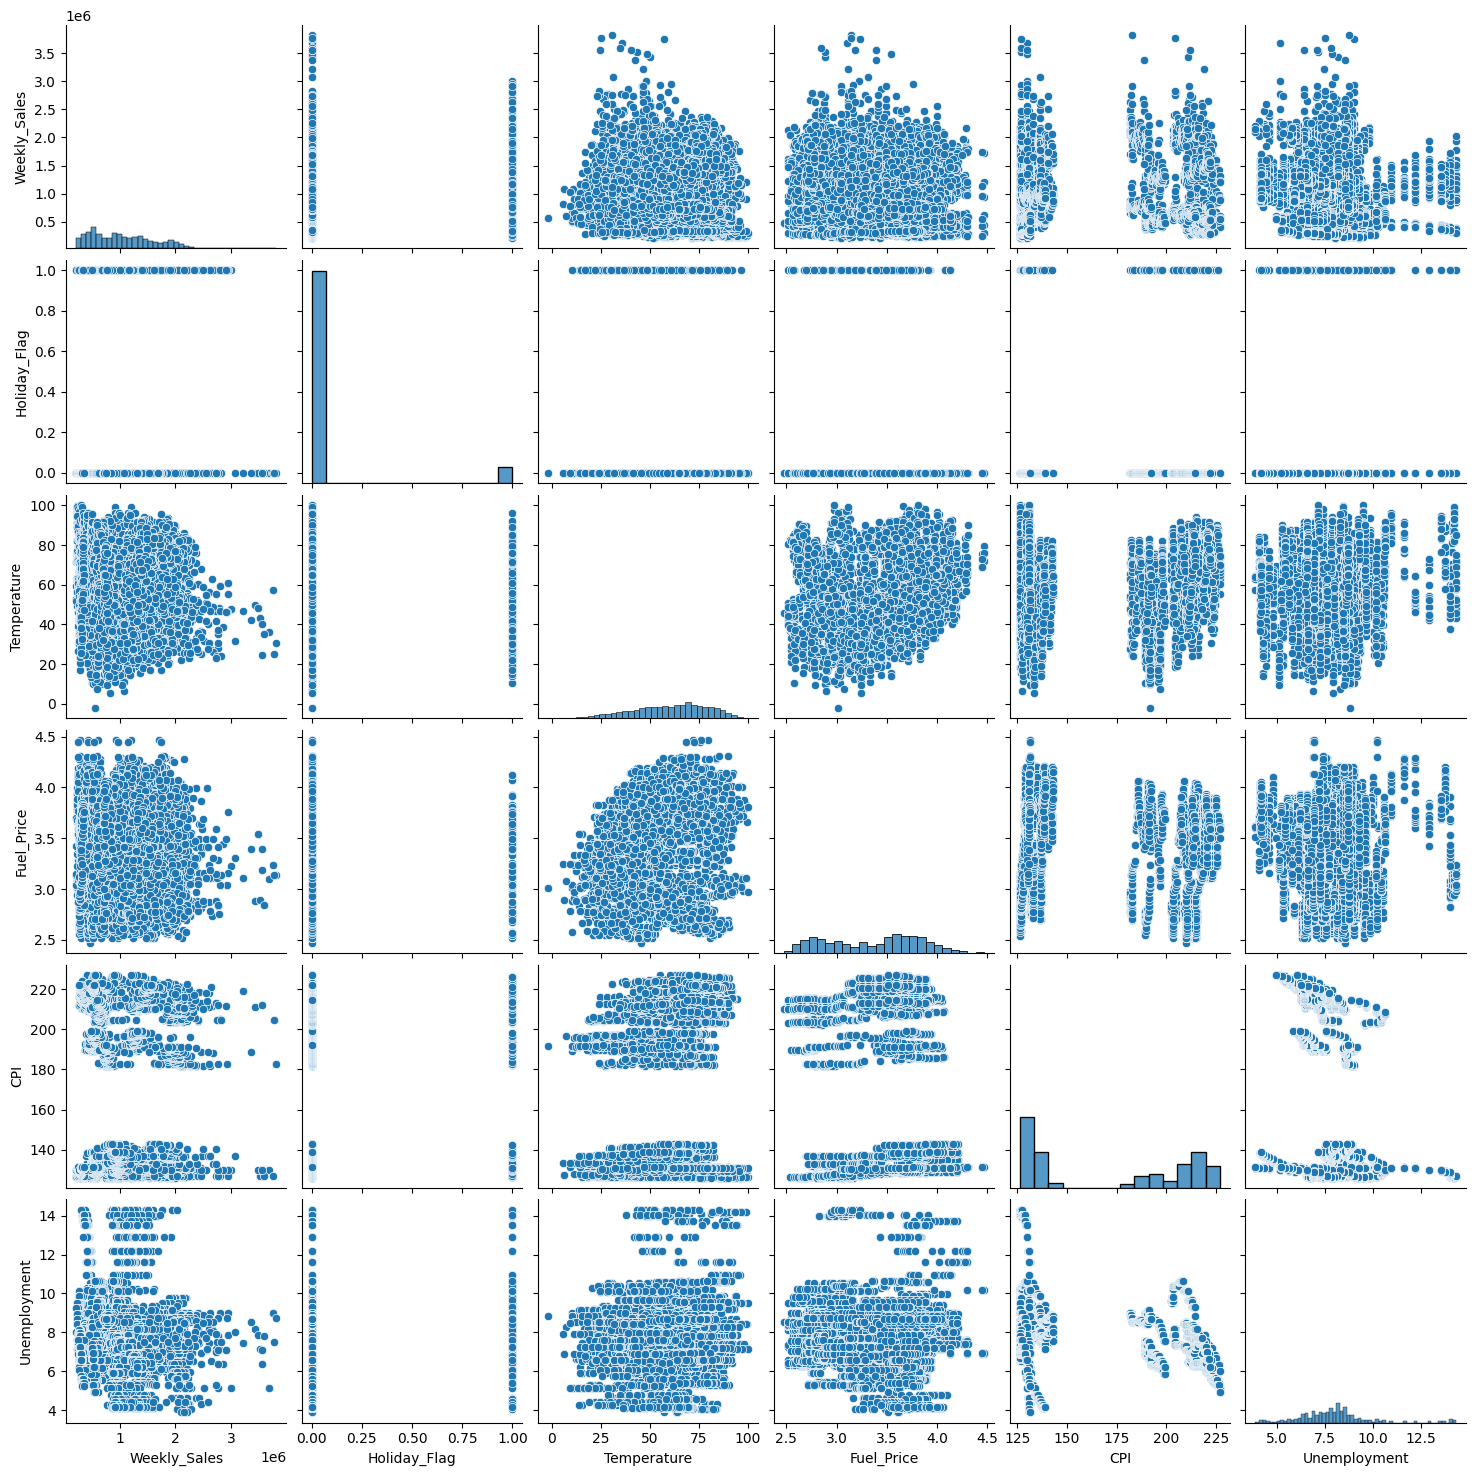

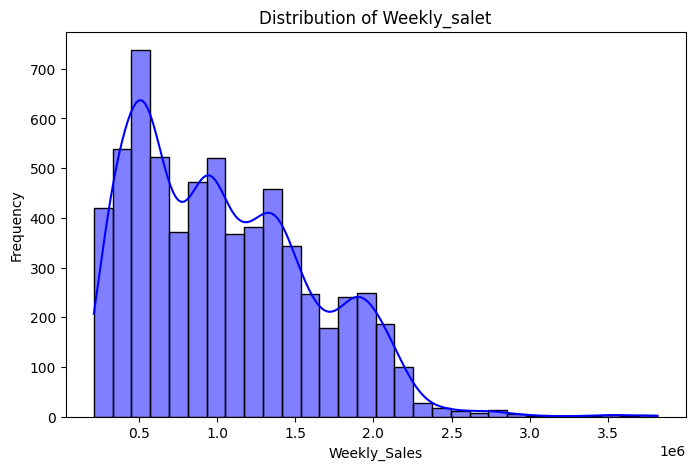

In [25]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly_salet")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frequency")
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales"])  # All columns except target
y = df["Weekly_Sales"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1555
RMSE: 521597.6144


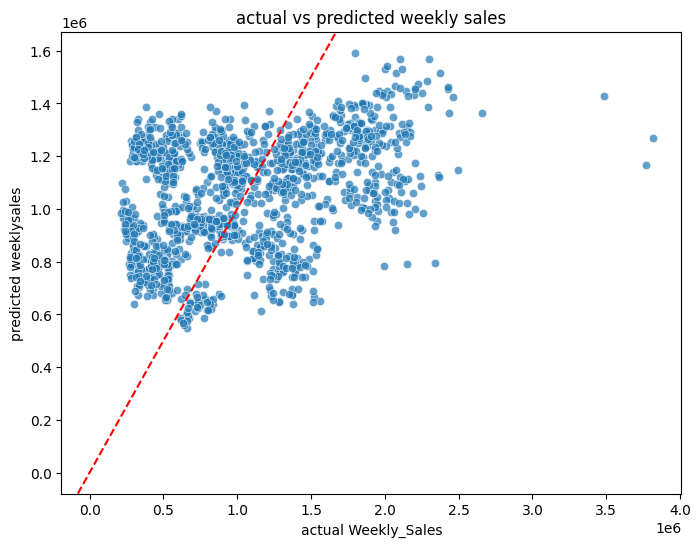

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("actual Weekly_Sales")
plt.ylabel("predicted weeklysales")
plt.title("actual vs predicted weekly sales")
plt.axline([0,0],[1,1],color = 'red',linestyle='--')
plt.show()

In [29]:
from scipy.stats import skew

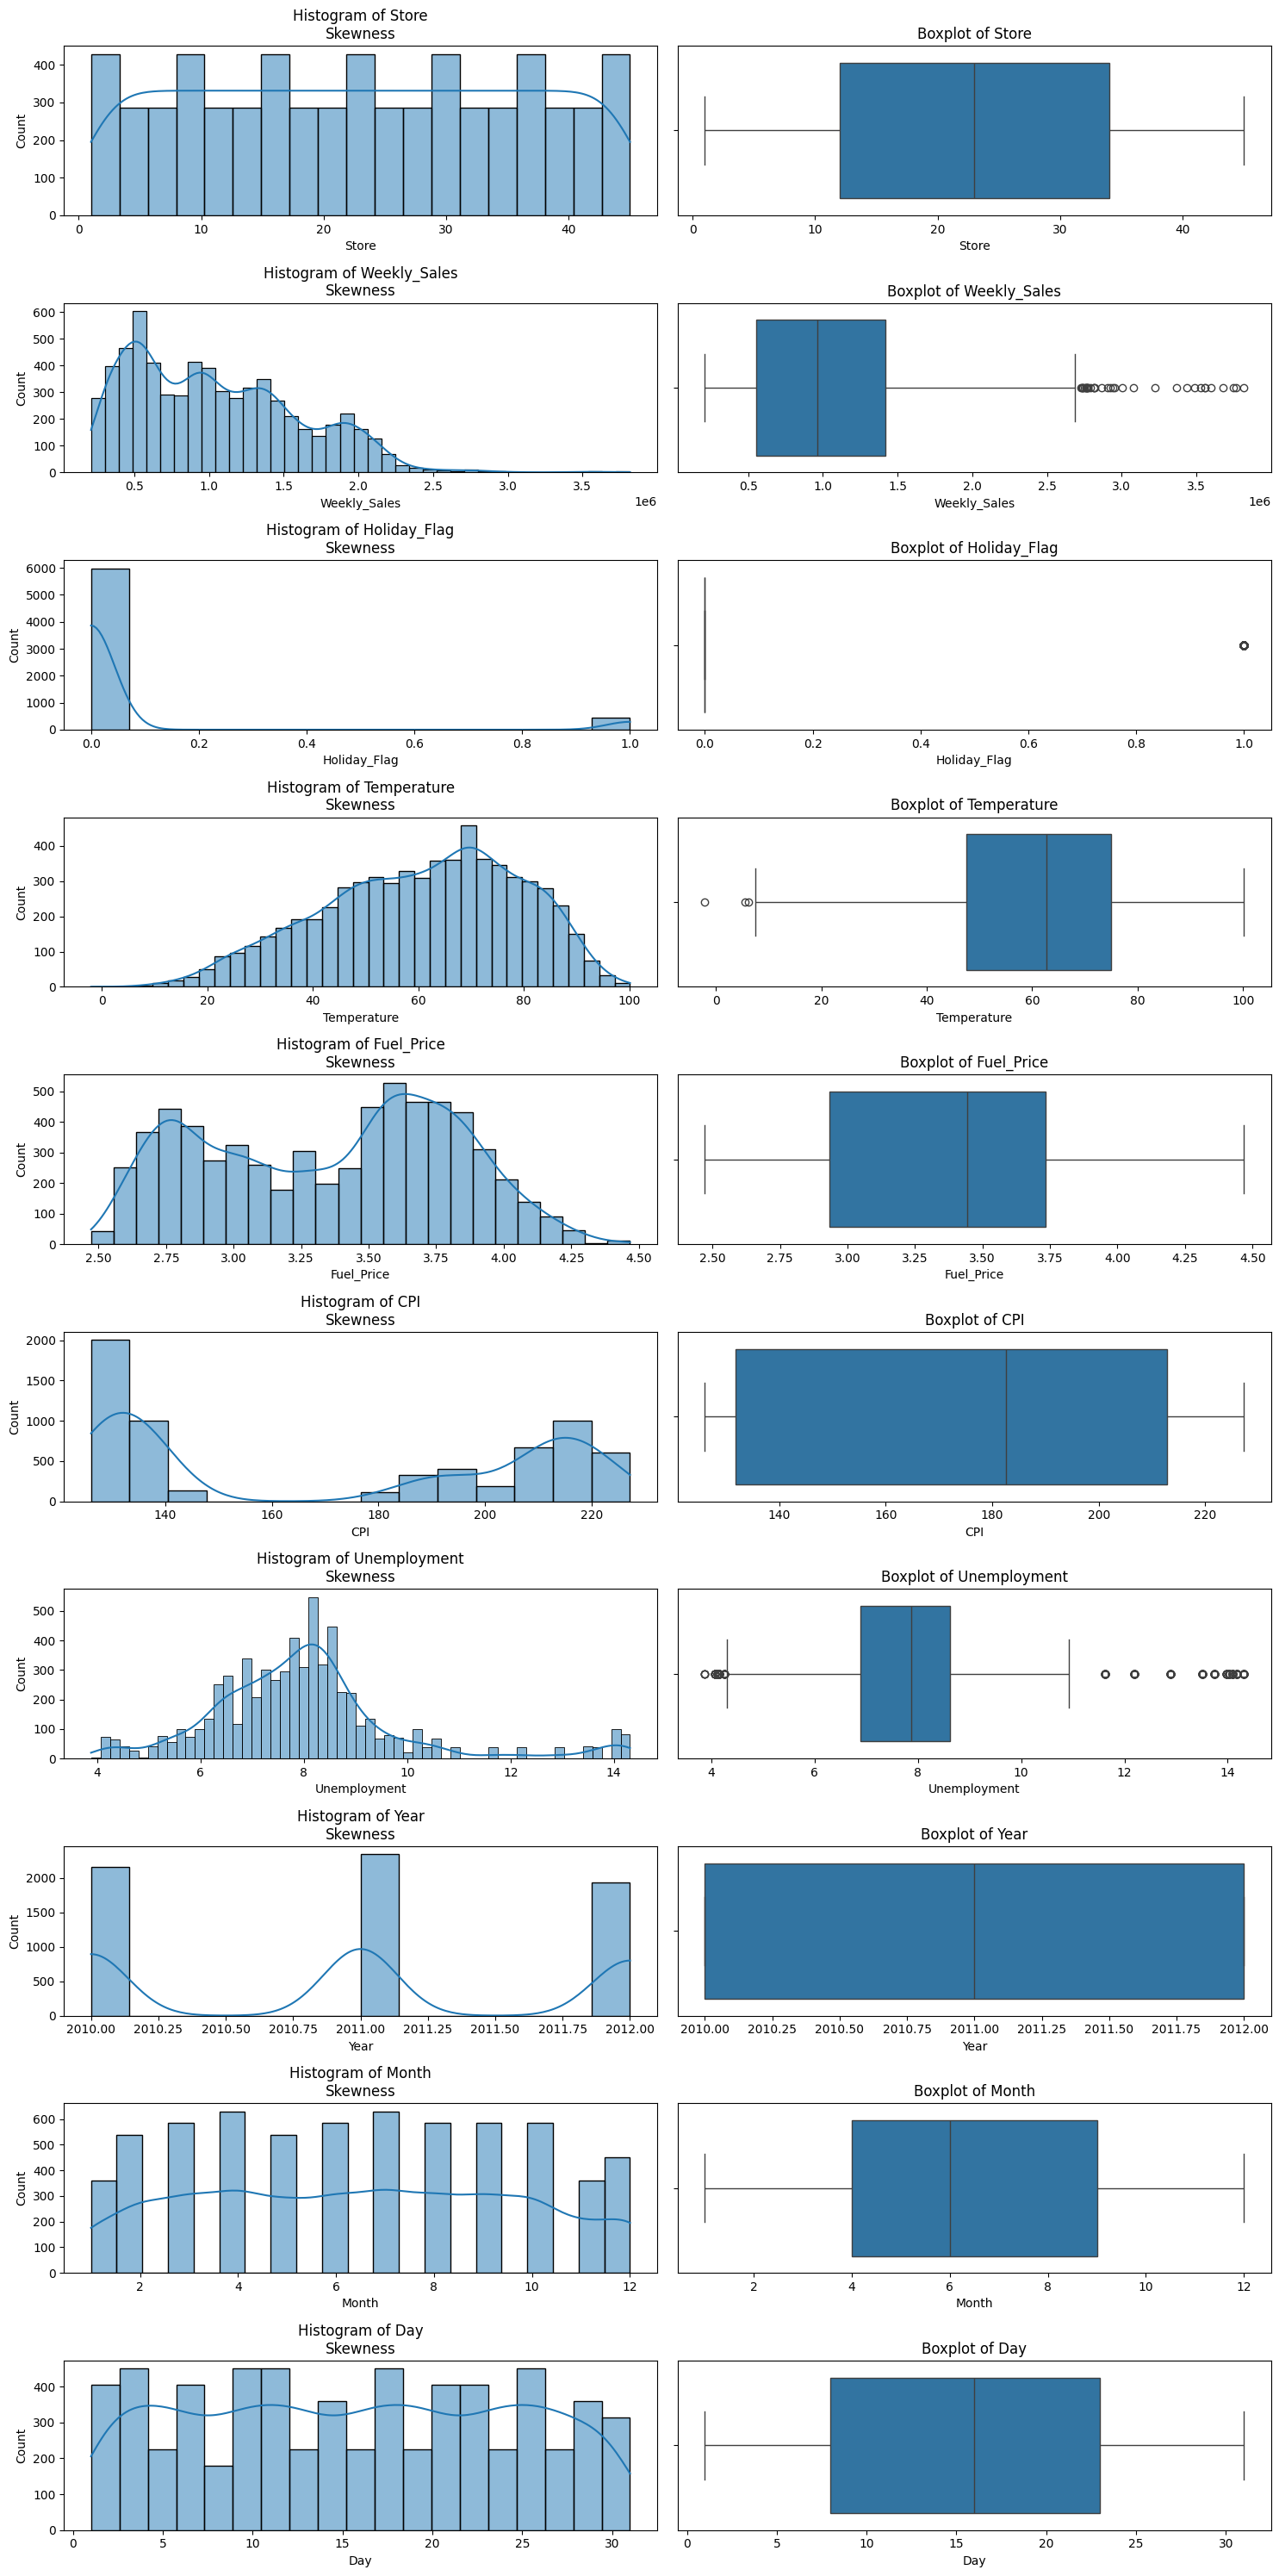

In [31]:
skewness = df.skew()

nums_cols = len(df.columns)
plt.figure(figsize=(15,nums_cols*3))

for i,col in enumerate(df.columns):
  plt.subplot(nums_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f'Histogram of {col}\nSkewness')

  plt.subplot(nums_cols,2,2*i+2)
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [32]:
skewness = df.skew()
print(skewness)

Store           0.000000
Weekly_Sales    0.668362
Holiday_Flag    3.373499
Temperature    -0.336768
Fuel_Price     -0.096158
CPI             0.063492
Unemployment    1.188144
Year            0.062642
Month           0.039568
Day             0.008512
dtype: float64


In [33]:
import numpy as np

skewed_cols = df.skew().abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
negatively_skewed = skewed_cols[skewed_cols < 1].index
print("highly skewed columns:\n",highly_skewed)
print("negatively skewed columns:\n",negatively_skewed)

highly skewed columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
negatively skewed columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [34]:
df[highly_skewed] = df[highly_skewed].apply(lambda x: np.log1p(x))

In [35]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df[negatively_skewed] = pt.fit_transform(df[negatively_skewed])

In [38]:
# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales"])  # All columns except target
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1336
RMSE: 0.9428


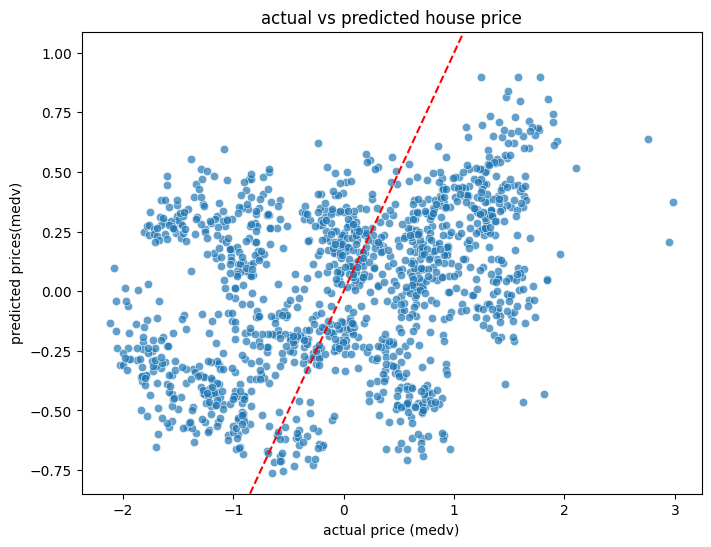

In [39]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("actual price (medv)")
plt.ylabel("predicted prices(medv)")
plt.title("actual vs predicted house price")
plt.axline([0,0],[1,1],color = 'red',linestyle='--')
plt.show()

In [40]:
#RANDOM FOREST REGRESSOR

from sklearn.ensemble import RandomForestRegressor

#train Random Forest

rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#predicts and evaluation

y_pred=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9762
RMSE: 0.1563


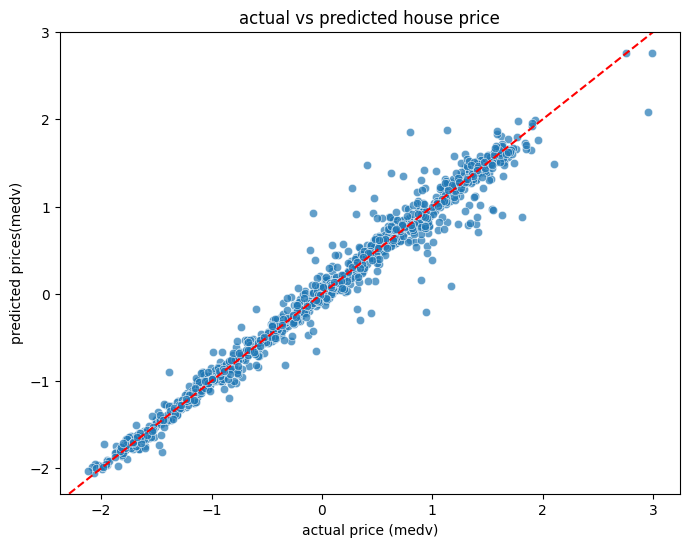

In [41]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("actual price (medv)")
plt.ylabel("predicted prices(medv)")
plt.title("actual vs predicted house price")
plt.axline([0,0],[1,1],color = 'red',linestyle='--')
plt.show()

In [42]:
df

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,-1.942666,1.062778,0.000000,-1.017966,-1.683544,1.006528,2.208934,-8.221201e-14,-1.429897,-1.239004
1,-1.942666,1.060635,0.693147,-1.204376,-1.732738,1.009450,2.208934,-8.221201e-14,-1.429897,-0.335247
2,-1.942666,1.023306,0.000000,-1.135341,-1.802251,1.010391,2.208934,-8.221201e-14,-1.429897,0.436415
3,-1.942666,0.757367,0.000000,-0.799809,-1.706104,1.011002,2.208934,-8.221201e-14,-1.429897,1.135378
4,-1.942666,0.950729,0.000000,-0.806467,-1.574543,1.011613,2.208934,-8.221201e-14,-1.059317,-1.239004
...,...,...,...,...,...,...,...,...,...,...
6430,1.554160,-0.454488,0.000000,0.186582,1.408278,0.604228,2.270475,8.809620e-14,0.801637,1.325422
6431,1.554160,-0.408915,0.000000,0.187148,1.380942,0.607706,2.268718,8.809620e-14,1.076394,-1.239004
6432,1.554160,-0.406671,0.000000,-0.388228,1.415115,0.611181,2.268718,8.809620e-14,1.076394,-0.335247
6433,1.554160,-0.443275,0.000000,-0.280200,1.344527,0.611260,2.268718,8.809620e-14,1.076394,0.436415


In [48]:
import pandas as pd
import numpy as np

# The sample data provided by the user
Store = 3
Date = '10-12-2014'
Holiday_Flag = 0
Temperature = 50.41
Fuel_Price = 3.701
CPI = 300.096358
Unemployment = 7.106

# Format into a dictionary with matching feature names
input_data = {
    'Store': [Store],
    'Date': [Date],
    'Holiday_Flag': [Holiday_Flag],
    'Temperature': [Temperature],
    'Fuel_Price': [Fuel_Price],
    'CPI': [CPI],
    'Unemployment': [Unemployment]
}

# Convert to DataFrame
sample_df = pd.DataFrame(input_data)

print("Original Sample Data:")
display(sample_df)

Original Sample Data:


,Store,Date,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,3,10-12-2014,0,50.41,3.701,300.096358,7.106


In [50]:
sample_df["Date"] = pd.to_datetime(sample_df["Date"])
sample_df["Year"] = sample_df["Date"].dt.year
sample_df["Month"] = sample_df["Date"].dt.month
sample_df["Day"] = sample_df["Date"].dt.day


sample_df = sample_df.drop(['Date'],axis=1)

In [51]:
prediction = rf_model.predict(sample_df)

print(f"Predicted Class: {prediction[0]}")

Predicted Class: -0.053101438062005124


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa

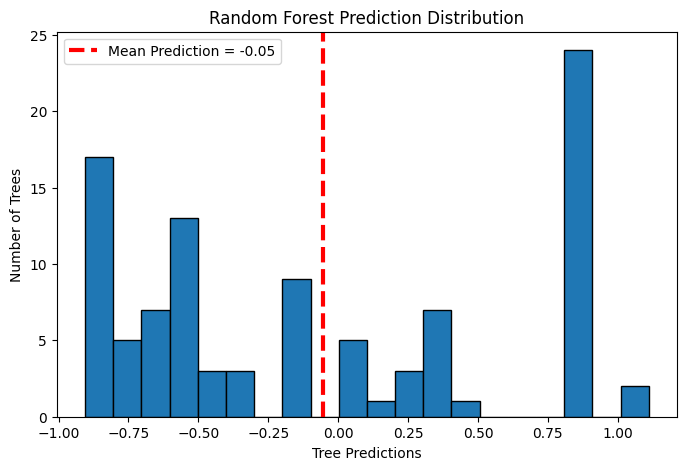

In [52]:
tree_predictions = np.array([
    tree.predict(sample_df)[0]
    for tree in rf_model.estimators_
])

plt.figure(figsize=(8,5))
plt.hist(tree_predictions, bins=20, edgecolor='black')
plt.axvline(
    tree_predictions.mean(),
    color='red',
    linestyle='--',
    linewidth=3,
    label=f'Mean Prediction = {tree_predictions.mean():.2f}'
)

plt.xlabel('Tree Predictions')
plt.ylabel('Number of Trees')
plt.title('Random Forest Prediction Distribution')
plt.legend()
plt.show()

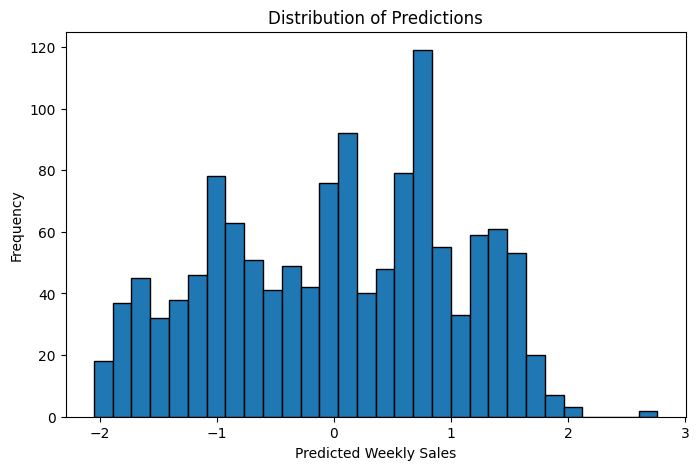

In [53]:
predictions = rf_model.predict(X_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(predictions, bins=30, edgecolor='black')
plt.xlabel('Predicted Weekly Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Predictions')
plt.show()